In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[3]
sys.path.insert(0, str(ROOT))

print("Project root:", ROOT)
BUCKET = "isign_bucket"
GCS_PREFIX_dataset = "iSign/datasets"
word_description_file = "word-description-dataset_v1.1.csv"  # ✅ no trailing space

LOCAL_POSE_DIR = ROOT / "dataset/task5_semantic_similarity/poses"
GCP_POSE_PREFIX = f"{BUCKET}/iSign/poses/iSign-poses_v1.1"




Project root: /Users/lokeshkumar/eMasters/EE964_Projects


In [11]:
from src.scripts.authenticate_GCP import authenticate_gcp

fs = authenticate_gcp()
print(fs.ls("isign_bucket"))


GCS filesystem initialized (explicit ADC).
['isign_bucket/iSign']


In [ ]:
import pandas as pd
import re
from tqdm import tqdm
import time


t0 = time.time()
df = pd.read_csv(f"gs://{BUCKET}/{GCS_PREFIX_dataset}/{word_description_file}")
t1 = time.time()
print("CSV read seconds:", time.time() - t0, "rows:", len(df))

POSE_PREFIX = f"{BUCKET}/iSign/poses/iSign-poses_v1.1"

def get_base_id(uid):
    return re.sub(r'_(w|d|e\d+)$', '', uid)

df["base_id"] = df["word_id"].apply(get_base_id)
print("get base ids in seconds:", time.time() - t1)

# 1) unique ids only
needed_ids = set(df["word_id"].values) | set(df["sentence_id"].values)
needed_ids = list(needed_ids)
# 2) check existence ONCE per unique id
exist_map = {}
t2 = time.time()

for uid in tqdm(needed_ids, desc="Checking poses"):
    exist_map[uid] = fs.exists(f"{POSE_PREFIX}/{uid}.pose")
print("exists seconds:", time.time() - t2)

# 3) map back to rows (fast, local)
word_ok = df["word_id"].map(exist_map).fillna(False)
sent_ok = df["sentence_id"].map(exist_map).fillna(False)

missing_words = df.loc[~word_ok, "word_id"].unique()
missing_descs = df.loc[~sent_ok, "sentence_id"].unique()

print("Missing word poses:", len(missing_words))
print("Missing description poses:", len(missing_descs))

df_clean = df[word_ok & sent_ok].reset_index(drop=True)
print("Usable rows:", len(df_clean), "/", len(df))
print(df_clean.head())
df_clean = df_clean[["word_id", "sentence_id"]].drop_duplicates().reset_index(drop=True)
df_clean.to_csv('/Users/lokeshkumar/eMasters/EE964_Projects/data/task5_semantic_similarity/cleaned_input.csv')

CSV read seconds: 1.656008005142212 rows: 593
get base ids in seconds: 0.0027561187744140625


Checking poses: 100%|██████████| 1177/1177 [06:18<00:00,  3.11it/s]

exists seconds: 379.0217900276184
Missing word poses: 0
Missing description poses: 12
Usable rows: 581 / 593
         word_id         word    sentence_id  \
0  j3cflScQLfo_w  qualitative  j3cflScQLfo_d   
1  O6Rvpy2XFfY_w         elan  O6Rvpy2XFfY_d   
2  mfp9Jb5pfEY_w      concept  mfp9Jb5pfEY_d   
3  pY5phP_7ebg_w        shill  pY5phP_7ebg_d   
4  wNZIAo8zLP0_w       attach  wNZIAo8zLP0_d   

                                            sentence      base_id  
0           relating to how good or bad something is  j3cflScQLfo  
1  a combination of style and energetic confidenc...  O6Rvpy2XFfY  
2                                  an abstract idea.  mfp9Jb5pfEY  
3                            act or work as a shill.  pY5phP_7ebg  
4              to fasten, join, or connect something  wNZIAo8zLP0  


In [8]:
from src.scripts.download_from_GCP import download_pose_files_from_gcs
download_pose_files_from_gcs(fs, df_clean, LOCAL_POSE_DIR, GCP_POSE_PREFIX)

Total pose files needed: 1153


100%|██████████| 1153/1153 [49:56<00:00,  2.60s/it] 

Downloaded now: 1153
Missing (404): 0
Forbidden (403/billing): 0


In [2]:
from src.tasks.task5_semantic_similarity.data.splits import create_splits, save_splits
import pandas as pd
df_clean = pd.read_csv('/Users/lokeshkumar/eMasters/EE964_Projects/dataset/task5_semantic_similarity/cleaned_input.csv')
train_pos, val_pos, test_pos, split_info = create_splits(df_clean, seed=1990)

print(split_info)

save_splits(
    train_pos,
    val_pos,
    test_pos,
    split_info,
    out_dir="/Users/lokeshkumar/eMasters/EE964_Projects/src/tasks/task5_semantic_similarity/dataset/splits/desc_disjoint"
)

{'seed': 1990, 'train_pairs': 464, 'val_pairs': 58, 'test_pairs': 59, 'train_unique_desc': 464, 'val_unique_desc': 58, 'test_unique_desc': 59, 'train_unique_words': 457, 'val_unique_words': 58, 'test_unique_words': 59, 'desc_overlap_train_val': 0, 'desc_overlap_train_test': 0, 'desc_overlap_val_test': 0}


In [11]:
from src.tasks.task5_semantic_similarity.data.dataset import load_pose
from src.tasks.task5_semantic_similarity.evaluation.baselines import statpool_retrieval_baseline

statpool_val_metrics = statpool_retrieval_baseline(
    val_df=val_pos,
    pose_dir=LOCAL_POSE_DIR,
    load_pose_fn=load_pose,
    max_word_frames=200,
    max_desc_frames=400
)

print(statpool_val_metrics)

{'num_queries': 58, 'num_candidates': 58, 'top5pct_k': 3, 'Top5%': 0.08620689655172414, 'MeanRank': 28.482758620689655, 'MedianRank': 28.5, 'MRR': 0.11461602920895474}


In [12]:
from torch.utils.data import DataLoader
import torch

from src.tasks.task5_semantic_similarity.data.dataset import Task5PairDataset
from src.tasks.task5_semantic_similarity.models.statpool_mlp import StatPoolMLP
from src.tasks.task5_semantic_similarity.training.train_statpool_mlp import train_one_epoch_statpool_mlp
from src.tasks.task5_semantic_similarity.evaluation.eval_statpool_mlp import eval_statpool_mlp_retrieval

train_dataset = Task5PairDataset(train_pos, LOCAL_POSE_DIR)
val_dataset = Task5PairDataset(val_pos, LOCAL_POSE_DIR)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = StatPoolMLP(input_dim=675, hidden_dim=256, output_dim=128, dropout=0.1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(1, 11):
    train_loss = train_one_epoch_statpool_mlp(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        temperature=0.07,
        grad_clip=1.0,
    )

    val_metrics = eval_statpool_mlp_retrieval(
        model=model,
        val_loader=val_loader,
        device=device,
    )

    print(f"Epoch {epoch:02d} | loss={train_loss:.4f} | val={val_metrics}")

Epoch 01 | loss=3.4394 | val={'num_queries': 58, 'num_candidates': 58, 'top5pct_k': 3, 'Top5%': 0.05172413793103448, 'MeanRank': 28.20689655172414, 'MedianRank': 30.0, 'MRR': 0.09879170101627216}
Epoch 02 | loss=3.4234 | val={'num_queries': 58, 'num_candidates': 58, 'top5pct_k': 3, 'Top5%': 0.034482758620689655, 'MeanRank': 27.948275862068964, 'MedianRank': 26.5, 'MRR': 0.08396306618745987}
Epoch 03 | loss=3.4230 | val={'num_queries': 58, 'num_candidates': 58, 'top5pct_k': 3, 'Top5%': 0.034482758620689655, 'MeanRank': 27.879310344827587, 'MedianRank': 27.5, 'MRR': 0.08499867783540256}
Epoch 04 | loss=3.4177 | val={'num_queries': 58, 'num_candidates': 58, 'top5pct_k': 3, 'Top5%': 0.034482758620689655, 'MeanRank': 27.086206896551722, 'MedianRank': 25.0, 'MRR': 0.08534960492124297}
Epoch 05 | loss=3.4171 | val={'num_queries': 58, 'num_candidates': 58, 'top5pct_k': 3, 'Top5%': 0.017241379310344827, 'MeanRank': 26.74137931034483, 'MedianRank': 25.0, 'MRR': 0.08041403262846902}
Epoch 06 | lo

In [13]:
from torch.utils.data import DataLoader
import torch

from src.tasks.task5_semantic_similarity.data.dataset import Task5PairDataset
from src.tasks.task5_semantic_similarity.models.meanpool_temporal import MeanPoolTemporalEncoder
from src.tasks.task5_semantic_similarity.training.train_meanpool_temporal import train_one_epoch_meanpool_temporal
from src.tasks.task5_semantic_similarity.evaluation.eval_meanpool_temporal import eval_meanpool_temporal_retrieval

train_dataset = Task5PairDataset(train_pos, LOCAL_POSE_DIR)
val_dataset = Task5PairDataset(val_pos, LOCAL_POSE_DIR)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = MeanPoolTemporalEncoder(
    input_dim=225,
    frame_hidden_dim=256,
    output_dim=128,
    dropout=0.1,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(1, 11):
    train_loss = train_one_epoch_meanpool_temporal(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
        temperature=0.07,
        grad_clip=1.0,
    )

    val_metrics = eval_meanpool_temporal_retrieval(
        model=model,
        val_loader=val_loader,
        device=device,
    )

    print(f"Epoch {epoch:02d} | loss={train_loss:.4f} | val={val_metrics}")

Epoch 01 | loss=3.2125 | val={'num_queries': 58, 'num_candidates': 58, 'top5pct_k': 3, 'Top5%': 0.3448275862068966, 'MeanRank': 13.431034482758621, 'MedianRank': 7.0, 'MRR': 0.25823376858605923}
Epoch 02 | loss=2.5306 | val={'num_queries': 58, 'num_candidates': 58, 'top5pct_k': 3, 'Top5%': 0.39655172413793105, 'MeanRank': 10.775862068965518, 'MedianRank': 6.0, 'MRR': 0.31770142052052514}
Epoch 03 | loss=2.0139 | val={'num_queries': 58, 'num_candidates': 58, 'top5pct_k': 3, 'Top5%': 0.39655172413793105, 'MeanRank': 9.03448275862069, 'MedianRank': 5.0, 'MRR': 0.3645484316559576}
Epoch 04 | loss=1.6866 | val={'num_queries': 58, 'num_candidates': 58, 'top5pct_k': 3, 'Top5%': 0.46551724137931033, 'MeanRank': 8.172413793103448, 'MedianRank': 4.5, 'MRR': 0.38767242309968547}
Epoch 05 | loss=1.3541 | val={'num_queries': 58, 'num_candidates': 58, 'top5pct_k': 3, 'Top5%': 0.5172413793103449, 'MeanRank': 8.844827586206897, 'MedianRank': 3.0, 'MRR': 0.41065293097094074}
Epoch 06 | loss=1.0541 | va

In [14]:
from pathlib import Path
from torch.utils.data import DataLoader
import torch

from src.tasks.task5_semantic_similarity.data.dataset import Task5PairDataset
from src.tasks.task5_semantic_similarity.models.meanpool_temporal import MeanPoolTemporalEncoder
from src.tasks.task5_semantic_similarity.training.train_meanpool_with_checkpoint import (
    train_meanpool_with_checkpoint,
)

train_dataset = Task5PairDataset(train_pos, LOCAL_POSE_DIR)
val_dataset = Task5PairDataset(val_pos, LOCAL_POSE_DIR)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

model = MeanPoolTemporalEncoder(
    input_dim=225,
    frame_hidden_dim=256,
    output_dim=128,
    dropout=0.1,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

SAVE_DIR = Path("/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/meanpool_temporal")

result = train_meanpool_with_checkpoint(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    save_dir=SAVE_DIR,
    num_epochs=20,
    temperature=0.07,
    grad_clip=1.0,
    patience=5,
)

print("\nBest result:")
print(result["best_epoch"], result["best_metrics"])

Epoch 01 | loss=3.1796 | Top5%=0.2759 | MeanRank=15.1552 | MRR=0.2431
  -> saved new best checkpoint
Epoch 02 | loss=2.5332 | Top5%=0.2586 | MeanRank=11.9483 | MRR=0.2272
  -> no improvement (1/5)
Epoch 03 | loss=1.9970 | Top5%=0.3966 | MeanRank=8.8793 | MRR=0.3391
  -> saved new best checkpoint
Epoch 04 | loss=1.5018 | Top5%=0.3966 | MeanRank=8.1379 | MRR=0.3566
  -> saved new best checkpoint
Epoch 05 | loss=1.2426 | Top5%=0.5000 | MeanRank=6.7759 | MRR=0.4256
  -> saved new best checkpoint
Epoch 06 | loss=0.9684 | Top5%=0.5172 | MeanRank=6.6207 | MRR=0.4382
  -> saved new best checkpoint
Epoch 07 | loss=0.7670 | Top5%=0.5172 | MeanRank=6.3448 | MRR=0.4745
  -> saved new best checkpoint
Epoch 08 | loss=0.5777 | Top5%=0.5690 | MeanRank=5.6552 | MRR=0.4770
  -> saved new best checkpoint
Epoch 09 | loss=0.5245 | Top5%=0.5517 | MeanRank=6.2586 | MRR=0.4601
  -> no improvement (1/5)
Epoch 10 | loss=0.4094 | Top5%=0.5690 | MeanRank=6.7069 | MRR=0.4376
  -> no improvement (2/5)
Epoch 11 | lo

In [13]:
from pathlib import Path
from torch.utils.data import DataLoader
import torch

from src.tasks.task5_semantic_similarity.data.dataset import Task5PairDataset
from src.tasks.task5_semantic_similarity.models.small_transformer import SmallTransformerEncoder
from src.tasks.task5_semantic_similarity.training.train_small_transformer_with_checkpoint import (
    train_small_transformer_with_checkpoint,
)

train_dataset = Task5PairDataset(train_pos, LOCAL_POSE_DIR)
val_dataset = Task5PairDataset(val_pos, LOCAL_POSE_DIR)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

model = SmallTransformerEncoder(
    input_dim=225,
    d_model=128,
    nhead=4,
    num_layers=1,
    ff_mult=2,
    output_dim=128,
    dropout=0.1,
    max_len=400,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

SAVE_DIR = Path("/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/small_transformer")

result = train_small_transformer_with_checkpoint(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    save_dir=SAVE_DIR,
    num_epochs=20,
    temperature=0.07,
    grad_clip=1.0,
    patience=5,
)

print("\nBest result:")
print(result["best_epoch"], result["best_metrics"])

Epoch 01 | loss=3.6717 | Top5%=0.1034 | MeanRank=24.1552 | MRR=0.1496
  -> saved new best checkpoint
Epoch 02 | loss=3.3984 | Top5%=0.1207 | MeanRank=23.1379 | MRR=0.1534
  -> saved new best checkpoint
Epoch 03 | loss=3.3208 | Top5%=0.1724 | MeanRank=20.6207 | MRR=0.1802
  -> saved new best checkpoint
Epoch 04 | loss=2.9901 | Top5%=0.2759 | MeanRank=14.2069 | MRR=0.2793
  -> saved new best checkpoint
Epoch 05 | loss=2.6762 | Top5%=0.2759 | MeanRank=14.5000 | MRR=0.2619
  -> no improvement (1/5)
Epoch 06 | loss=2.4664 | Top5%=0.3276 | MeanRank=12.5517 | MRR=0.2712
  -> saved new best checkpoint
Epoch 07 | loss=2.1150 | Top5%=0.3793 | MeanRank=10.2759 | MRR=0.2928
  -> saved new best checkpoint
Epoch 08 | loss=1.9553 | Top5%=0.3621 | MeanRank=10.8276 | MRR=0.2834
  -> no improvement (1/5)
Epoch 09 | loss=1.7057 | Top5%=0.4483 | MeanRank=10.1724 | MRR=0.3330
  -> saved new best checkpoint
Epoch 10 | loss=1.4860 | Top5%=0.5000 | MeanRank=9.6897 | MRR=0.3982
  -> saved new best checkpoint
E

In [14]:
from pathlib import Path
import torch
from torch.utils.data import DataLoader

from src.tasks.task5_semantic_similarity.data.dataset import Task5PairDataset
from src.tasks.task5_semantic_similarity.models.meanpool_temporal import MeanPoolTemporalEncoder
from src.tasks.task5_semantic_similarity.evaluation.eval_checkpoint import (
    load_checkpoint,
    evaluate_model_retrieval,
)

test_dataset = Task5PairDataset(test_pos, LOCAL_POSE_DIR)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

device = "cpu"

model = MeanPoolTemporalEncoder(
    input_dim=225,
    frame_hidden_dim=256,
    output_dim=128,
)

checkpoint_path = Path(
    "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/meanpool_temporal/best_model.pt"
)

model, ckpt = load_checkpoint(model, checkpoint_path, device)

test_metrics = evaluate_model_retrieval(
    model,
    test_loader,
    device,
)

print("MeanPool TEST metrics:")
print(test_metrics)

MeanPool TEST metrics:
{'num_queries': 59, 'num_candidates': 59, 'top5pct_k': 3, 'Top5%': 0.5254237288135594, 'MeanRank': 7.101694915254237, 'MedianRank': 3.0, 'MRR': 0.40183974539079953}


In [15]:
from src.tasks.task5_semantic_similarity.models.small_transformer import SmallTransformerEncoder

model = SmallTransformerEncoder(
    input_dim=225,
    d_model=128,
    nhead=4,
    num_layers=1,
    ff_mult=2,
    output_dim=128,
    dropout=0.1,
    max_len=400,
)

checkpoint_path = Path(
    "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/small_transformer/best_model.pt"
)

model, ckpt = load_checkpoint(model, checkpoint_path, device)

test_metrics = evaluate_model_retrieval(
    model,
    test_loader,
    device,
)

print("Transformer TEST metrics:")
print(test_metrics)

Transformer TEST metrics:
{'num_queries': 59, 'num_candidates': 59, 'top5pct_k': 3, 'Top5%': 0.3728813559322034, 'MeanRank': 10.88135593220339, 'MedianRank': 6.0, 'MRR': 0.32476308653946906}


In [16]:
from src.tasks.task5_semantic_similarity.data.dataset import load_pose
from src.tasks.task5_semantic_similarity.evaluation.baselines import statpool_retrieval_baseline

statpool_test_metrics = statpool_retrieval_baseline(
    val_df=test_pos,              # function name says val_df, but any split df works
    pose_dir=LOCAL_POSE_DIR,
    load_pose_fn=load_pose,
    max_word_frames=200,
    max_desc_frames=400
)

print("StatPool TEST metrics:")
print(statpool_test_metrics)

StatPool TEST metrics:
{'num_queries': 59, 'num_candidates': 59, 'top5pct_k': 3, 'Top5%': 0.05084745762711865, 'MeanRank': 29.864406779661017, 'MedianRank': 30.0, 'MRR': 0.0801092746828646}


In [17]:
from pathlib import Path
from torch.utils.data import DataLoader
import torch

from src.tasks.task5_semantic_similarity.data.dataset import Task5PairDataset
from src.tasks.task5_semantic_similarity.models.meanpool_temporal import MeanPoolTemporalEncoder
from src.tasks.task5_semantic_similarity.training.train_meanpool_with_checkpoint import (
    train_meanpool_with_checkpoint,
)

train_dataset = Task5PairDataset(train_pos, LOCAL_POSE_DIR)
val_dataset = Task5PairDataset(val_pos, LOCAL_POSE_DIR)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

model = MeanPoolTemporalEncoder(
    input_dim=225,
    frame_hidden_dim=256,
    output_dim=128,
    dropout=0.1,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

SAVE_DIR = Path(
    "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/meanpool_temporal"
)

result = train_meanpool_with_checkpoint(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    save_dir=SAVE_DIR,
    num_epochs=20,
    temperature=0.07,
    grad_clip=1.0,
    patience=5,
)

print("\nBest result:")
print(result["best_epoch"], result["best_metrics"])

Epoch 01 | loss=3.2956 | Top5%=0.2586 | MeanRank=15.6897 | MRR=0.2282
  -> saved new best checkpoint
Epoch 02 | loss=2.7392 | Top5%=0.3276 | MeanRank=9.7759 | MRR=0.2848
  -> saved new best checkpoint
Epoch 03 | loss=2.1173 | Top5%=0.3276 | MeanRank=10.1552 | MRR=0.3204
  -> no improvement (1/5)
Epoch 04 | loss=1.7040 | Top5%=0.3966 | MeanRank=8.1034 | MRR=0.3580
  -> saved new best checkpoint
Epoch 05 | loss=1.2696 | Top5%=0.4310 | MeanRank=6.9828 | MRR=0.4225
  -> saved new best checkpoint
Epoch 06 | loss=0.9982 | Top5%=0.5172 | MeanRank=6.9310 | MRR=0.4386
  -> saved new best checkpoint
Epoch 07 | loss=0.7849 | Top5%=0.5517 | MeanRank=6.3448 | MRR=0.4488
  -> saved new best checkpoint
Epoch 08 | loss=0.7220 | Top5%=0.5000 | MeanRank=7.1379 | MRR=0.4362
  -> no improvement (1/5)
Epoch 09 | loss=0.6271 | Top5%=0.5690 | MeanRank=6.6552 | MRR=0.4767
  -> saved new best checkpoint
Epoch 10 | loss=0.4855 | Top5%=0.5517 | MeanRank=6.5345 | MRR=0.4829
  -> no improvement (1/5)
Epoch 11 | lo

In [19]:
from pathlib import Path
from torch.utils.data import DataLoader
import torch

from src.tasks.task5_semantic_similarity.data.dataset import Task5PairDataset
from src.tasks.task5_semantic_similarity.models.meanpool_temporal import MeanPoolTemporalEncoder
from src.tasks.task5_semantic_similarity.evaluation.eval_meanpool_checkpoint import (
    load_meanpool_checkpoint,
    eval_meanpool_retrieval,
)

test_dataset = Task5PairDataset(test_pos, LOCAL_POSE_DIR)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

model = MeanPoolTemporalEncoder(
    input_dim=225,
    frame_hidden_dim=256,
    output_dim=128,
    dropout=0.1,
)

checkpoint_path = Path(
    "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/meanpool_temporal/best_model.pt"
)

model, ckpt = load_meanpool_checkpoint(model, checkpoint_path, device)

meanpool_test_metrics = eval_meanpool_retrieval(
    model=model,
    loader=test_loader,
    device=device,
)

print("MeanPool TEST metrics:")
print(meanpool_test_metrics)

MeanPool TEST metrics:
{'num_queries': 59, 'num_candidates': 59, 'top5pct_k': 3, 'Top5%': 0.4745762711864407, 'MeanRank': 7.661016949152542, 'MedianRank': 4.0, 'MRR': 0.392280576000469}


In [4]:
# =========================
# TASK-5 PRECHECK BUNDLE
# =========================
# Ready-to-run notebook code for:
# 1) reproducibility seed setup
# 2) split integrity checks from saved CSVs
# 3) data loading sanity
# 4) checkpoint existence + metric file check
# 5) repeated evaluation consistency
# 6) runtime smoke test (5 epochs)
# 7) history inspection summary
# 8) experiment registry bootstrap
#
# Adjust only these paths if needed.

from pathlib import Path
import json
import time
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

# -------------------------
# PATHS
# -------------------------
REPO_ROOT = Path("/Users/lokeshkumar/eMasters/EE964_Projects")
TASK5_DATA_DIR = REPO_ROOT / "dataset" / "task5_semantic_similarity"
SPLITS_DIR = TASK5_DATA_DIR / "splits"
POSE_DIR = TASK5_DATA_DIR / "poses"

RESULTS_DIR = REPO_ROOT / "results" / "task5_semantic_similarity"
MEANPOOL_DIR = RESULTS_DIR / "meanpool_temporal"
TRANSFORMER_DIR = RESULTS_DIR / "small_transformer"

REGISTRY_PATH = RESULTS_DIR / "experiment_registry.csv"

# -------------------------
# IMPORTS FROM YOUR PROJECT
# -------------------------
from src.tasks.task5_semantic_similarity.data.dataset import Task5PairDataset
from src.tasks.task5_semantic_similarity.models.meanpool_temporal import MeanPoolTemporalEncoder
from src.tasks.task5_semantic_similarity.models.small_transformer import SmallTransformerEncoder
from src.tasks.task5_semantic_similarity.evaluation.eval_meanpool_checkpoint import (
    load_meanpool_checkpoint,
    eval_meanpool_retrieval,
)
from src.tasks.task5_semantic_similarity.evaluation.eval_checkpoint import (
    load_checkpoint,
    evaluate_model_retrieval,
)
from src.tasks.task5_semantic_similarity.training.train_meanpool_temporal import (
    train_one_epoch_meanpool_temporal,
)
from src.tasks.task5_semantic_similarity.training.train_small_transformer import (
    train_one_epoch_small_transformer,
)

# -------------------------
# 1) REPRODUCIBILITY SETUP
# -------------------------
SEED = 1990

def set_all_seeds(seed=1990):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Determinism toggles
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(SEED)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

print("Seeds set to:", SEED)

# -------------------------
# DEVICE
# -------------------------
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print("Using device:", DEVICE)

# -------------------------
# 2) LOAD SAVED SPLITS
# -------------------------
train_pos = pd.read_csv(SPLITS_DIR / "train_pos.csv")
val_pos   = pd.read_csv(SPLITS_DIR / "val_pos.csv")
test_pos  = pd.read_csv(SPLITS_DIR / "test_pos.csv")

print("\n=== SPLIT SIZES ===")
print("train:", train_pos.shape)
print("val:  ", val_pos.shape)
print("test: ", test_pos.shape)

# Normalize column names if needed
assert {"word_id", "sentence_id"}.issubset(train_pos.columns), "train_pos.csv must contain word_id, sentence_id"
assert {"word_id", "sentence_id"}.issubset(val_pos.columns), "val_pos.csv must contain word_id, sentence_id"
assert {"word_id", "sentence_id"}.issubset(test_pos.columns), "test_pos.csv must contain word_id, sentence_id"

# -------------------------
# 3) SPLIT INTEGRITY CHECKS
# -------------------------
train_desc = set(train_pos["sentence_id"].unique())
val_desc   = set(val_pos["sentence_id"].unique())
test_desc  = set(test_pos["sentence_id"].unique())

train_word = set(train_pos["word_id"].unique())
val_word   = set(val_pos["word_id"].unique())
test_word  = set(test_pos["word_id"].unique())

print("\n=== SPLIT INTEGRITY ===")
print("desc overlap train/val :", len(train_desc & val_desc))
print("desc overlap train/test:", len(train_desc & test_desc))
print("desc overlap val/test  :", len(val_desc & test_desc))

print("word overlap train/val :", len(train_word & val_word))
print("word overlap train/test:", len(train_word & test_word))
print("word overlap val/test  :", len(val_word & test_word))

assert len(train_desc & val_desc) == 0
assert len(train_desc & test_desc) == 0
assert len(val_desc & test_desc) == 0
print("Description split integrity: PASS")

# -------------------------
# 4) DATASET + DATALOADER SANITY
# -------------------------
train_dataset = Task5PairDataset(train_pos, str(POSE_DIR))
val_dataset   = Task5PairDataset(val_pos, str(POSE_DIR))
test_dataset  = Task5PairDataset(test_pos, str(POSE_DIR))

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    worker_init_fn=seed_worker,
    generator=g,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
)

batch = next(iter(train_loader))

print("\n=== DATALOADER SANITY ===")
print("word_data shape:", batch["word_data"].shape)
print("word_mask shape:", batch["word_mask"].shape)
print("desc_data shape:", batch["desc_data"].shape)
print("desc_mask shape:", batch["desc_mask"].shape)

print("word valid frames min/max:",
      int(batch["word_mask"].sum(dim=1).min().item()),
      int(batch["word_mask"].sum(dim=1).max().item()))
print("desc valid frames min/max:",
      int(batch["desc_mask"].sum(dim=1).min().item()),
      int(batch["desc_mask"].sum(dim=1).max().item()))

print("NaNs in word_data:", torch.isnan(batch["word_data"]).any().item())
print("NaNs in desc_data:", torch.isnan(batch["desc_data"]).any().item())

assert not torch.isnan(batch["word_data"]).any()
assert not torch.isnan(batch["desc_data"]).any()
print("Data loading sanity: PASS")

# -------------------------
# 5) CHECKPOINT + METRICS FILE CHECK
# -------------------------
print("\n=== CHECKPOINT FILE CHECK ===")

required_meanpool = [
    MEANPOOL_DIR / "best_model.pt",
    MEANPOOL_DIR / "best_metrics.json",
    MEANPOOL_DIR / "history.json",
]
required_transformer = [
    TRANSFORMER_DIR / "best_model.pt",
    TRANSFORMER_DIR / "best_metrics.json",
    TRANSFORMER_DIR / "history.json",
]

for p in required_meanpool:
    print("meanpool exists:", p.name, p.exists())

for p in required_transformer:
    print("transformer exists:", p.name, p.exists())

assert all(p.exists() for p in required_meanpool), "Missing meanpool result files"
assert all(p.exists() for p in required_transformer), "Missing transformer result files"

with open(MEANPOOL_DIR / "best_metrics.json", "r") as f:
    meanpool_best_json = json.load(f)

with open(TRANSFORMER_DIR / "best_metrics.json", "r") as f:
    transformer_best_json = json.load(f)

print("\nMeanPool best_metrics.json:", meanpool_best_json)
print("Transformer best_metrics.json:", transformer_best_json)

# -------------------------
# 6) REPEATED EVALUATION CONSISTENCY
# -------------------------
print("\n=== REPEATED EVALUATION CONSISTENCY ===")

# MeanPool
meanpool_model = MeanPoolTemporalEncoder(
    input_dim=225,
    frame_hidden_dim=256,
    output_dim=128,
    dropout=0.1,
)
meanpool_model, _ = load_meanpool_checkpoint(
    meanpool_model,
    MEANPOOL_DIR / "best_model.pt",
    DEVICE,
)

meanpool_eval_1 = eval_meanpool_retrieval(meanpool_model, test_loader, DEVICE)
meanpool_eval_2 = eval_meanpool_retrieval(meanpool_model, test_loader, DEVICE)

print("MeanPool eval #1:", meanpool_eval_1)
print("MeanPool eval #2:", meanpool_eval_2)
assert meanpool_eval_1 == meanpool_eval_2, "MeanPool repeated evaluation mismatch"

# Transformer
transformer_model = SmallTransformerEncoder(
    input_dim=225,
    d_model=128,
    nhead=4,
    num_layers=1,
    ff_mult=2,
    output_dim=128,
    dropout=0.1,
    max_len=400,
)
transformer_model, _ = load_checkpoint(
    transformer_model,
    TRANSFORMER_DIR / "best_model.pt",
    DEVICE,
)

transformer_eval_1 = evaluate_model_retrieval(transformer_model, test_loader, DEVICE)
transformer_eval_2 = evaluate_model_retrieval(transformer_model, test_loader, DEVICE)

print("Transformer eval #1:", transformer_eval_1)
print("Transformer eval #2:", transformer_eval_2)
assert transformer_eval_1 == transformer_eval_2, "Transformer repeated evaluation mismatch"

print("Repeated evaluation consistency: PASS")

# -------------------------
# 7) RUNTIME SMOKE TEST (5 EPOCHS)
# -------------------------
print("\n=== RUNTIME SMOKE TEST (5 epochs) ===")

def time_meanpool_5_epochs():
    set_all_seeds(SEED)
    model = MeanPoolTemporalEncoder(
        input_dim=225,
        frame_hidden_dim=256,
        output_dim=128,
        dropout=0.1,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-4,
    )

    t0 = time.time()
    for _ in range(5):
        train_one_epoch_meanpool_temporal(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=DEVICE,
            temperature=0.07,
            grad_clip=1.0,
        )
    return time.time() - t0


def time_transformer_5_epochs():
    set_all_seeds(SEED)
    model = SmallTransformerEncoder(
        input_dim=225,
        d_model=128,
        nhead=4,
        num_layers=1,
        ff_mult=2,
        output_dim=128,
        dropout=0.1,
        max_len=400,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-4,
    )

    t0 = time.time()
    for _ in range(5):
        train_one_epoch_small_transformer(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=DEVICE,
            temperature=0.07,
            grad_clip=1.0,
        )
    return time.time() - t0

meanpool_5ep_sec = time_meanpool_5_epochs()
print(f"MeanPool 5 epochs: {meanpool_5ep_sec:.2f} sec")

transformer_5ep_sec = time_transformer_5_epochs()
print(f"Transformer 5 epochs: {transformer_5ep_sec:.2f} sec")

# -------------------------
# 8) HISTORY INSPECTION SUMMARY
# -------------------------
print("\n=== HISTORY INSPECTION SUMMARY ===")

with open(MEANPOOL_DIR / "history.json", "r") as f:
    meanpool_history = json.load(f)

with open(TRANSFORMER_DIR / "history.json", "r") as f:
    transformer_history = json.load(f)

meanpool_hist_df = pd.DataFrame(meanpool_history)
transformer_hist_df = pd.DataFrame(transformer_history)

def summarize_history(df, name):
    best_top5_row = df.sort_values(["Top5%", "MeanRank"], ascending=[False, True]).iloc[0]
    min_loss_row = df.sort_values("train_loss", ascending=True).iloc[0]

    print(f"\n{name}")
    print("-" * len(name))
    print("epochs run:", len(df))
    print("best Top5% epoch:", int(best_top5_row["epoch"]))
    print("best Top5%:", float(best_top5_row["Top5%"]))
    print("MeanRank at best Top5%:", float(best_top5_row["MeanRank"]))
    print("MRR at best Top5%:", float(best_top5_row["MRR"]))
    print("lowest train loss epoch:", int(min_loss_row["epoch"]))
    print("lowest train loss:", float(min_loss_row["train_loss"]))
    print("last epoch Top5%:", float(df.iloc[-1]["Top5%"]))
    print("last epoch MeanRank:", float(df.iloc[-1]["MeanRank"]))

summarize_history(meanpool_hist_df, "MeanPool History")
summarize_history(transformer_hist_df, "Transformer History")

# Optional quick view
print("\nMeanPool history head:")
print(meanpool_hist_df.head())

print("\nTransformer history head:")
print(transformer_hist_df.head())

# -------------------------
# 9) EXPERIMENT REGISTRY BOOTSTRAP
# -------------------------
print("\n=== EXPERIMENT REGISTRY BOOTSTRAP ===")

registry_rows = [
    {
        "model_name": "meanpool_temporal",
        "best_epoch": meanpool_best_json.get("best_epoch"),
        "val_top5": meanpool_best_json.get("Top5%"),
        "val_meanrank": meanpool_best_json.get("MeanRank"),
        "val_mrr": meanpool_best_json.get("MRR"),
        "test_top5": meanpool_eval_1.get("Top5%"),
        "test_meanrank": meanpool_eval_1.get("MeanRank"),
        "test_mrr": meanpool_eval_1.get("MRR"),
        "notes": "frozen improved baseline",
    },
    {
        "model_name": "small_transformer",
        "best_epoch": transformer_best_json.get("best_epoch"),
        "val_top5": transformer_best_json.get("Top5%"),
        "val_meanrank": transformer_best_json.get("MeanRank"),
        "val_mrr": transformer_best_json.get("MRR"),
        "test_top5": transformer_eval_1.get("Top5%"),
        "test_meanrank": transformer_eval_1.get("MeanRank"),
        "test_mrr": transformer_eval_1.get("MRR"),
        "notes": "1-layer transformer baseline",
    },
]

registry_df = pd.DataFrame(registry_rows)
registry_df.to_csv(REGISTRY_PATH, index=False)

print("Saved registry to:", REGISTRY_PATH)
print(registry_df)

print("\n=== PRECHECKS COMPLETE ===")

Seeds set to: 1990
Using device: mps

=== SPLIT SIZES ===
train: (464, 2)
val:   (58, 2)
test:  (59, 2)

=== SPLIT INTEGRITY ===
desc overlap train/val : 0
desc overlap train/test: 0
desc overlap val/test  : 0
word overlap train/val : 0
word overlap train/test: 0
word overlap val/test  : 0
Description split integrity: PASS

=== DATALOADER SANITY ===
word_data shape: torch.Size([32, 200, 225])
word_mask shape: torch.Size([32, 200])
desc_data shape: torch.Size([32, 400, 225])
desc_mask shape: torch.Size([32, 400])
word valid frames min/max: 118 200
desc valid frames min/max: 131 400
NaNs in word_data: False
NaNs in desc_data: False
Data loading sanity: PASS

=== CHECKPOINT FILE CHECK ===
meanpool exists: best_model.pt True
meanpool exists: best_metrics.json True
meanpool exists: history.json True
transformer exists: best_model.pt True
transformer exists: best_metrics.json True
transformer exists: history.json True

MeanPool best_metrics.json: {'best_epoch': 9, 'num_queries': 58, 'num_can

In [5]:
from pathlib import Path

from src.tasks.task5_semantic_similarity.training.grid_search import run_grid_search

RESULTS_ROOT = "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity"
POSE_DIR = LOCAL_POSE_DIR

In [24]:
meanpool_grid = {
    "frame_hidden_dim": [128, 256],
    "output_dim": [128],
    "dropout": [0.1, 0.2],
    "lr": [1e-3, 5e-4],
    "weight_decay": [1e-4],
    "batch_size": [32],
    "temperature": [0.07],
    "grad_clip": [1.0],
}

meanpool_ranked = run_grid_search(
    model_type="meanpool",
    param_grid=meanpool_grid,
    train_pos=train_pos,
    val_pos=val_pos,
    pose_dir=POSE_DIR,
    results_root=RESULTS_ROOT,
    num_epochs=20,
    patience=5,
    num_workers=2,
)

Running 8 configs for model_type=meanpool

[1/8] model_type=meanpool
{'frame_hidden_dim': 128, 'output_dim': 128, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 32, 'temperature': 0.07, 'grad_clip': 1.0}
Epoch 01 | loss=3.3047 | Top5%=0.2241 | MeanRank=16.8448 | MRR=0.1859
  -> saved new best checkpoint
Epoch 02 | loss=2.7055 | Top5%=0.2931 | MeanRank=12.6207 | MRR=0.2577
  -> saved new best checkpoint
Epoch 03 | loss=2.2236 | Top5%=0.2759 | MeanRank=9.3966 | MRR=0.2853
  -> no improvement (1/5)
Epoch 04 | loss=1.8427 | Top5%=0.3966 | MeanRank=8.4655 | MRR=0.3115
  -> saved new best checkpoint
Epoch 05 | loss=1.4865 | Top5%=0.4655 | MeanRank=8.1724 | MRR=0.3706
  -> saved new best checkpoint
Epoch 06 | loss=1.2506 | Top5%=0.5345 | MeanRank=7.8448 | MRR=0.3772
  -> saved new best checkpoint
Epoch 07 | loss=1.0830 | Top5%=0.5000 | MeanRank=7.5345 | MRR=0.3841
  -> no improvement (1/5)
Epoch 08 | loss=0.9422 | Top5%=0.5172 | MeanRank=8.0517 | MRR=0.3958
  -> no improve

In [25]:
transformer_grid = {
    "d_model": [128, 256],
    "nhead": [4],
    "num_layers": [1, 2],
    "ff_mult": [2],
    "output_dim": [128],
    "dropout": [0.1, 0.2],
    "lr": [1e-3, 5e-4],
    "weight_decay": [1e-4],
    "batch_size": [32],
    "temperature": [0.07],
    "grad_clip": [1.0],
    "max_len": [400],
}

transformer_ranked = run_grid_search(
    model_type="transformer",
    param_grid=transformer_grid,
    train_pos=train_pos,
    val_pos=val_pos,
    pose_dir=POSE_DIR,
    results_root=RESULTS_ROOT,
    num_epochs=20,
    patience=5,
    num_workers=2,
)

Running 16 configs for model_type=transformer

[1/16] model_type=transformer
{'d_model': 128, 'nhead': 4, 'num_layers': 1, 'ff_mult': 2, 'output_dim': 128, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 32, 'temperature': 0.07, 'grad_clip': 1.0, 'max_len': 400}
Epoch 01 | loss=3.6054 | Top5%=0.0862 | MeanRank=26.2069 | MRR=0.0962
  -> saved new best checkpoint
Epoch 02 | loss=3.3913 | Top5%=0.1207 | MeanRank=21.9138 | MRR=0.1422
  -> saved new best checkpoint
Epoch 03 | loss=3.3030 | Top5%=0.1552 | MeanRank=18.3103 | MRR=0.1717
  -> saved new best checkpoint
Epoch 04 | loss=3.1019 | Top5%=0.2414 | MeanRank=15.2931 | MRR=0.2201
  -> saved new best checkpoint
Epoch 05 | loss=2.8327 | Top5%=0.2759 | MeanRank=14.0862 | MRR=0.2479
  -> saved new best checkpoint
Epoch 06 | loss=2.4835 | Top5%=0.2931 | MeanRank=11.9483 | MRR=0.2473
  -> saved new best checkpoint
Epoch 07 | loss=2.1558 | Top5%=0.3103 | MeanRank=10.1207 | MRR=0.2682
  -> saved new best checkpoint
Epoch 08 | 

python(59409) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 04 | loss=2.6263 | Top5%=0.3276 | MeanRank=12.7414 | MRR=0.2885
  -> saved new best checkpoint
Epoch 05 | loss=2.3642 | Top5%=0.2586 | MeanRank=11.5690 | MRR=0.2517
  -> no improvement (1/5)
Epoch 06 | loss=2.0711 | Top5%=0.4483 | MeanRank=9.5862 | MRR=0.3462
  -> saved new best checkpoint
Epoch 07 | loss=1.7924 | Top5%=0.3793 | MeanRank=10.1897 | MRR=0.3192
  -> no improvement (1/5)
Epoch 08 | loss=1.5896 | Top5%=0.4483 | MeanRank=10.6379 | MRR=0.3405
  -> no improvement (2/5)
Epoch 09 | loss=1.4199 | Top5%=0.4483 | MeanRank=9.5345 | MRR=0.3847
  -> saved new best checkpoint
Epoch 10 | loss=1.1711 | Top5%=0.4828 | MeanRank=8.8621 | MRR=0.3862
  -> saved new best checkpoint
Epoch 11 | loss=1.0897 | Top5%=0.4655 | MeanRank=9.0517 | MRR=0.3303
  -> no improvement (1/5)


python(69137) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(70413) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch 12 | loss=1.0409 | Top5%=0.5172 | MeanRank=8.3276 | MRR=0.3875
  -> saved new best checkpoint
Epoch 13 | loss=0.8812 | Top5%=0.4483 | MeanRank=9.6552 | MRR=0.3537
  -> no improvement (1/5)
Epoch 14 | loss=0.8566 | Top5%=0.4655 | MeanRank=9.4310 | MRR=0.3521
  -> no improvement (2/5)
Epoch 15 | loss=0.7058 | Top5%=0.4138 | MeanRank=8.4655 | MRR=0.3511
  -> no improvement (3/5)
Epoch 16 | loss=0.6615 | Top5%=0.4828 | MeanRank=8.2759 | MRR=0.3905
  -> no improvement (4/5)
Epoch 17 | loss=0.5798 | Top5%=0.3966 | MeanRank=9.3276 | MRR=0.3251
  -> no improvement (5/5)

Early stopping at epoch 17. Best epoch: 12
BEST | epoch=12 | Top5%=0.5172 | MeanRank=8.3276 | MRR=0.3875

[16/16] model_type=transformer
{'d_model': 256, 'nhead': 4, 'num_layers': 2, 'ff_mult': 2, 'output_dim': 128, 'dropout': 0.2, 'lr': 0.0005, 'weight_decay': 0.0001, 'batch_size': 32, 'temperature': 0.07, 'grad_clip': 1.0, 'max_len': 400}
Epoch 01 | loss=3.4969 | Top5%=0.1034 | MeanRank=23.5345 | MRR=0.1266
  -> saved 

In [6]:
transformer_grid = {
    "d_model": [128, 256],
    "nhead": [8],
    "num_layers": [1, 2],
    "ff_mult": [4],
    "output_dim": [128],
    "dropout": [0.1, 0.2],
    "lr": [1e-3, 5e-4],
    "weight_decay": [1e-4],
    "batch_size": [32],
    "temperature": [0.07],
    "grad_clip": [1.0],
    "max_len": [400],
}

transformer_ranked = run_grid_search(
    model_type="transformer",
    param_grid=transformer_grid,
    train_pos=train_pos,
    val_pos=val_pos,
    pose_dir=POSE_DIR,
    results_root=RESULTS_ROOT,
    num_epochs=20,
    patience=5,
    num_workers=2,
)

Running 16 configs for model_type=transformer

[1/16] model_type=transformer
{'d_model': 128, 'nhead': 8, 'num_layers': 1, 'ff_mult': 4, 'output_dim': 128, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 32, 'temperature': 0.07, 'grad_clip': 1.0, 'max_len': 400}
Epoch 01 | loss=3.5876 | Top5%=0.0690 | MeanRank=26.2759 | MRR=0.1152
  -> saved new best checkpoint
Epoch 02 | loss=3.4052 | Top5%=0.1034 | MeanRank=23.1897 | MRR=0.1207
  -> saved new best checkpoint
Epoch 03 | loss=3.3374 | Top5%=0.1724 | MeanRank=20.2069 | MRR=0.1484
  -> saved new best checkpoint
Epoch 04 | loss=3.1561 | Top5%=0.2069 | MeanRank=16.2069 | MRR=0.2268
  -> saved new best checkpoint
Epoch 05 | loss=2.8703 | Top5%=0.2414 | MeanRank=14.0000 | MRR=0.2413
  -> saved new best checkpoint
Epoch 06 | loss=2.4522 | Top5%=0.2759 | MeanRank=11.6379 | MRR=0.2871
  -> saved new best checkpoint
Epoch 07 | loss=2.2342 | Top5%=0.3276 | MeanRank=10.0345 | MRR=0.2904
  -> saved new best checkpoint
Epoch 08 | 

In [7]:
from pathlib import Path
import pandas as pd
import torch
from torch.utils.data import DataLoader

from src.tasks.task5_semantic_similarity.data.dataset import Task5PairDataset, load_pose
from src.tasks.task5_semantic_similarity.evaluation.baselines import statpool_retrieval_baseline
from src.tasks.task5_semantic_similarity.evaluation.eval_checkpoint import (
    load_checkpoint,
    evaluate_model_retrieval,
)
from src.tasks.task5_semantic_similarity.models.meanpool_temporal import MeanPoolTemporalEncoder
from src.tasks.task5_semantic_similarity.models.small_transformer import SmallTransformerEncoder

# -----------------------------
# Paths
# -----------------------------
POSE_DIR = LOCAL_POSE_DIR

MEANPOOL_CKPT = Path(
    "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/meanpool/fh256_out128_do0p1_lr0p0005_wd0p0001_bs32/best_model.pt"
)

TRANSFORMER_CKPT = Path(
    "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/transformer/dm128_nh4_nl1_ff2_out128_do0p2_lr0p001_wd0p0001_bs32/best_model.pt"
)

# -----------------------------
# Device
# -----------------------------
device = "cpu"   # safest for checkpoint eval

# -----------------------------
# Test loader
# -----------------------------
test_dataset = Task5PairDataset(test_pos, POSE_DIR)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# -----------------------------
# 1) StatPool baseline on test
# -----------------------------
statpool_test_metrics = statpool_retrieval_baseline(
    val_df=test_pos,   # function name says val_df, but it works for any split df
    pose_dir=POSE_DIR,
    load_pose_fn=load_pose,
    max_word_frames=200,
    max_desc_frames=400,
)

print("StatPool TEST metrics:")
print(statpool_test_metrics)

# -----------------------------
# 2) MeanPool best checkpoint on test
# -----------------------------
meanpool_model = MeanPoolTemporalEncoder(
    input_dim=225,
    frame_hidden_dim=256,
    output_dim=128,
    dropout=0.1,
)

meanpool_model, meanpool_ckpt = load_checkpoint(meanpool_model, MEANPOOL_CKPT, device)

meanpool_test_metrics = evaluate_model_retrieval(
    model=meanpool_model,
    loader=test_loader,
    device=device,
)

print("\nMeanPool TEST metrics:")
print(meanpool_test_metrics)

# -----------------------------
# 3) Transformer best checkpoint on test
# -----------------------------
transformer_model = SmallTransformerEncoder(
    input_dim=225,
    d_model=128,
    nhead=4,
    num_layers=1,
    ff_mult=2,
    output_dim=128,
    dropout=0.2,
    max_len=400,
)

transformer_model, transformer_ckpt = load_checkpoint(
    transformer_model,
    TRANSFORMER_CKPT,
    device,
)

transformer_test_metrics = evaluate_model_retrieval(
    model=transformer_model,
    loader=test_loader,
    device=device,
)

print("\nTransformer TEST metrics:")
print(transformer_test_metrics)

# -----------------------------
# Final comparison table
# -----------------------------
rows = [
    {
        "Model": "StatPool",
        **statpool_test_metrics
    },
    {
        "Model": "MeanPool Temporal",
        **meanpool_test_metrics
    },
    {
        "Model": "Small Transformer",
        **transformer_test_metrics
    },
]

results_df = pd.DataFrame(rows)[
    ["Model", "num_queries", "num_candidates", "top5pct_k", "Top5%", "MeanRank", "MedianRank", "MRR"]
]

print("\nFinal TEST comparison table:")
print(results_df.sort_values(by=["Top5%", "MeanRank"], ascending=[False, True]).reset_index(drop=True))

StatPool TEST metrics:
{'num_queries': 59, 'num_candidates': 59, 'top5pct_k': 3, 'Top5%': 0.05084745762711865, 'MeanRank': 29.864406779661017, 'MedianRank': 30.0, 'MRR': 0.0801092746828646}

MeanPool TEST metrics:
{'num_queries': 59, 'num_candidates': 59, 'top5pct_k': 3, 'Top5%': 0.4915254237288136, 'MeanRank': 7.576271186440678, 'MedianRank': 4.0, 'MRR': 0.4417308741907315}

Transformer TEST metrics:
{'num_queries': 59, 'num_candidates': 59, 'top5pct_k': 3, 'Top5%': 0.4406779661016949, 'MeanRank': 7.728813559322034, 'MedianRank': 4.0, 'MRR': 0.3975573707763865}

Final TEST comparison table:
               Model  num_queries  num_candidates  top5pct_k     Top5%  \
0  MeanPool Temporal           59              59          3  0.491525   
1  Small Transformer           59              59          3  0.440678   
2           StatPool           59              59          3  0.050847   

    MeanRank  MedianRank       MRR  
0   7.576271         4.0  0.441731  
1   7.728814         4.0  0.39

In [8]:
from pathlib import Path
import pandas as pd
import json

from src.tasks.task5_semantic_similarity.evaluation.plots import (
    plot_test_metric_bars,
    plot_val_vs_test_top5,
    plot_history_curves,
    make_meanpool_heatmap_from_ranked,
    make_transformer_heatmap_from_ranked,
)

FIG_DIR = Path("/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
from pathlib import Path
import pandas as pd
import json

from src.tasks.task5_semantic_similarity.evaluation.plots import (
    plot_test_metric_bars,
    plot_val_vs_test_top5,
    plot_history_curves,
    make_meanpool_heatmap_from_ranked,
    make_transformer_heatmap_from_ranked,
)

FIG_DIR = Path("/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [10]:
val_test_df = pd.DataFrame([
    {
        "Model": "StatPool",
        "ValTop5": 0.08620689655172414,
        "TestTop5": 0.05084745762711865,
    },
    {
        "Model": "MeanPool Temporal",
        "ValTop5": 0.6724137931034483,
        "TestTop5": 0.4915254237288136,
    },
    {
        "Model": "Small Transformer",
        "ValTop5": 0.5862068965517241,
        "TestTop5": 0.4406779661016949,
    },
])

plot_val_vs_test_top5(val_test_df, FIG_DIR)
print("Saved val vs test Top-5% chart to:", FIG_DIR)

Saved val vs test Top-5% chart to: /Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures


In [11]:
meanpool_history_path = "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/meanpool/fh256_out128_do0p1_lr0p0005_wd0p0001_bs32/history.json"

plot_history_curves(
    history_json_path=meanpool_history_path,
    save_dir=FIG_DIR,
    prefix="meanpool_best"
)

print("Saved meanpool training curves to:", FIG_DIR)

Saved meanpool training curves to: /Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures


In [12]:
meanpool_ranked_path = "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/meanpool/grid_search_results.json"

with open(meanpool_ranked_path, "r") as f:
    meanpool_ranked = json.load(f)

make_meanpool_heatmap_from_ranked(meanpool_ranked, FIG_DIR)
print("Saved meanpool heatmaps to:", FIG_DIR)

Saved meanpool heatmaps to: /Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures


In [13]:
transformer_ranked_path = "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/transformer/grid_search_results.json"

with open(transformer_ranked_path, "r") as f:
    transformer_ranked = json.load(f)

make_transformer_heatmap_from_ranked(transformer_ranked, FIG_DIR)
print("Saved transformer heatmaps to:", FIG_DIR)

Saved transformer heatmaps to: /Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures


In [14]:
from src.tasks.task5_semantic_similarity.utils.figure_utils import (
    list_figures,
    preview_figures
)

FIG_DIR = "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures"

In [15]:
list_figures(FIG_DIR)

meanpool_best_train_loss.png
meanpool_best_val_meanrank.png
meanpool_best_val_top5.png
meanpool_heatmap_fh128.png
meanpool_heatmap_fh256.png
transformer_heatmap_dm128_nh8_nl1_ff4.png
transformer_heatmap_dm128_nh8_nl2_ff4.png
transformer_heatmap_dm256_nh8_nl1_ff4.png
transformer_heatmap_dm256_nh8_nl2_ff4.png
val_vs_test_top5.png


[PosixPath('/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures/meanpool_best_train_loss.png'),
 PosixPath('/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures/meanpool_best_val_meanrank.png'),
 PosixPath('/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures/meanpool_best_val_top5.png'),
 PosixPath('/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures/meanpool_heatmap_fh128.png'),
 PosixPath('/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures/meanpool_heatmap_fh256.png'),
 PosixPath('/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures/transformer_heatmap_dm128_nh8_nl1_ff4.png'),
 PosixPath('/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures/transformer_heatmap_dm128_nh8_nl2_ff4.png'),
 PosixPath('/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semant

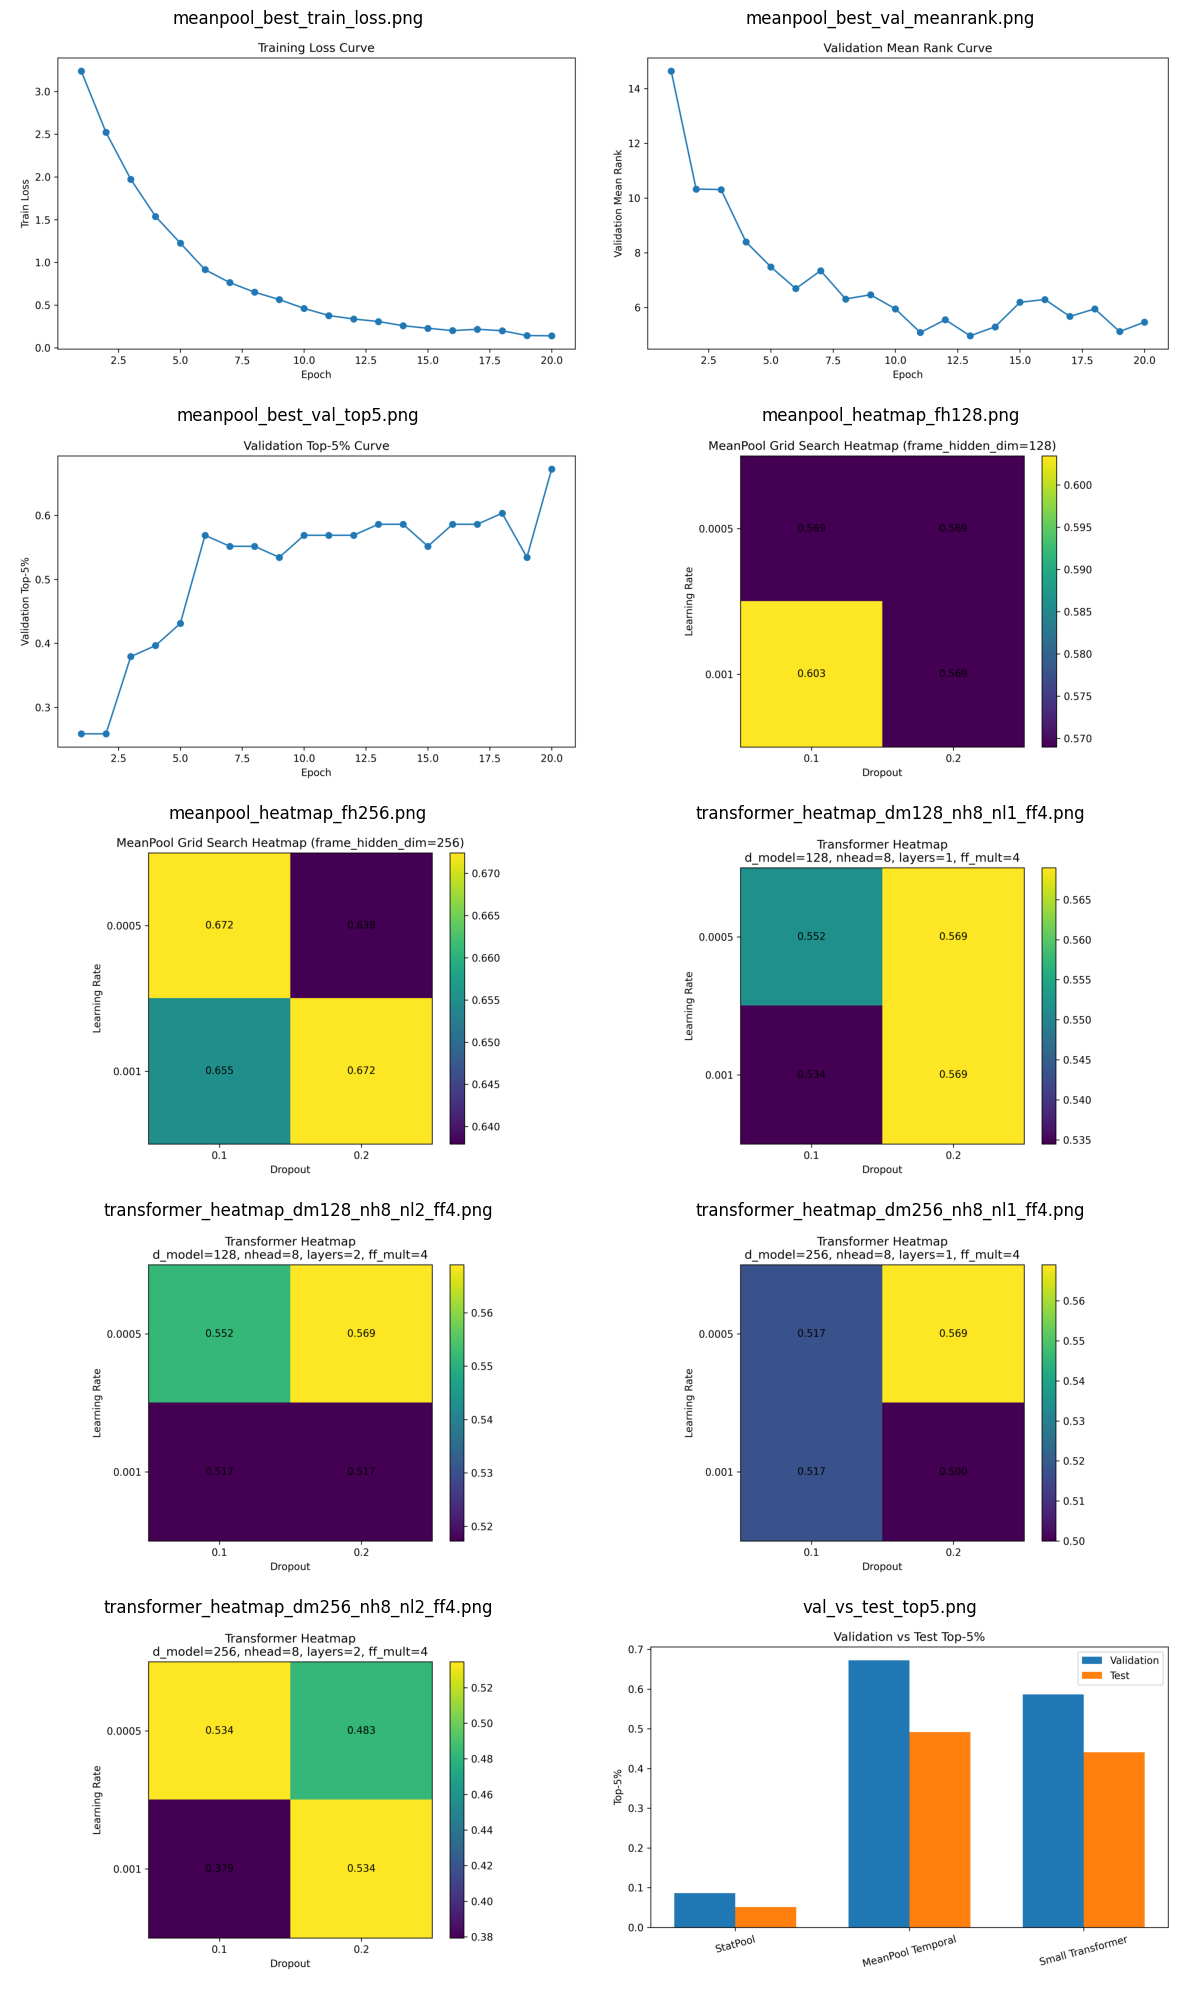

In [16]:
preview_figures(FIG_DIR)

In [3]:
import torch
from pathlib import Path

from src.tasks.task5_semantic_similarity.models.meanpool_temporal import MeanPoolTemporalEncoder
from src.tasks.task5_semantic_similarity.evaluation.eval_checkpoint import load_checkpoint

device = "cpu"

MEANPOOL_CKPT = Path(
"/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/meanpool/fh256_out128_do0p1_lr0p0005_wd0p0001_bs32/best_model.pt"
)

meanpool_model = MeanPoolTemporalEncoder(
    input_dim=225,
    frame_hidden_dim=256,
    output_dim=128,
    dropout=0.1,
)

meanpool_model, ckpt = load_checkpoint(meanpool_model, MEANPOOL_CKPT, device)

meanpool_model.eval()

print("Loaded MeanPool checkpoint")

Loaded MeanPool checkpoint


In [4]:
from torch.utils.data import DataLoader
from src.tasks.task5_semantic_similarity.data.dataset import Task5PairDataset

POSE_DIR = LOCAL_POSE_DIR

test_dataset = Task5PairDataset(test_pos, POSE_DIR)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
)

In [8]:
from src.tasks.task5_semantic_similarity.evaluation.plots import plot_similarity_heatmap

FIG_DIR = "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures"

plot_similarity_heatmap(
    model=meanpool_model,
    loader=test_loader,
    device=device,
    save_path=f"{FIG_DIR}/meanpool_similarity_heatmap.png",
    max_queries=30
)


In [5]:
import torch
from pathlib import Path
from torch.utils.data import DataLoader

from src.tasks.task5_semantic_similarity.data.dataset import Task5PairDataset
from src.tasks.task5_semantic_similarity.models.small_transformer import SmallTransformerEncoder
from src.tasks.task5_semantic_similarity.evaluation.eval_checkpoint import load_checkpoint
from src.tasks.task5_semantic_similarity.evaluation.plots import plot_similarity_heatmap_generic

device = "cpu"

TRANSFORMER_CKPT = Path(
    "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/transformer/dm128_nh4_nl1_ff2_out128_do0p2_lr0p001_wd0p0001_bs32/best_model.pt"
)

transformer_model = SmallTransformerEncoder(
    input_dim=225,
    d_model=128,
    nhead=4,
    num_layers=1,
    ff_mult=2,
    output_dim=128,
    dropout=0.2,
    max_len=400,
)

transformer_model, _ = load_checkpoint(transformer_model, TRANSFORMER_CKPT, device)

test_dataset = Task5PairDataset(test_pos, LOCAL_POSE_DIR)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

FIG_DIR = "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures"

plot_similarity_heatmap_generic(
    model=transformer_model,
    loader=test_loader,
    device=device,
    save_path=f"{FIG_DIR}/transformer_similarity_heatmap.png",
    max_queries=30,
    title="Transformer Retrieval Similarity Heatmap"
)

print("Saved transformer similarity heatmap.")

Saved transformer similarity heatmap.


In [6]:
import torch
from pathlib import Path
from torch.utils.data import DataLoader

from src.tasks.task5_semantic_similarity.data.dataset import Task5PairDataset
from src.tasks.task5_semantic_similarity.models.meanpool_temporal import MeanPoolTemporalEncoder
from src.tasks.task5_semantic_similarity.evaluation.eval_checkpoint import load_checkpoint
from src.tasks.task5_semantic_similarity.evaluation.plots import (
    collect_retrieval_case_study,
    plot_retrieval_case_study,
    pick_best_and_worst_cases,
)

device = "cpu"

MEANPOOL_CKPT = Path(
    "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/meanpool/fh256_out128_do0p1_lr0p0005_wd0p0001_bs32/best_model.pt"
)

meanpool_model = MeanPoolTemporalEncoder(
    input_dim=225,
    frame_hidden_dim=256,
    output_dim=128,
    dropout=0.1,
)

meanpool_model, _ = load_checkpoint(meanpool_model, MEANPOOL_CKPT, device)

test_dataset = Task5PairDataset(test_pos, LOCAL_POSE_DIR)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

cases = collect_retrieval_case_study(
    model=meanpool_model,
    loader=test_loader,
    device=device,
    top_k=5,
)

best_case, worst_case = pick_best_and_worst_cases(cases)

FIG_DIR = "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures"

plot_retrieval_case_study(
    best_case,
    save_path=f"{FIG_DIR}/meanpool_case_best.png",
    title_prefix="MeanPool Best Retrieval Example"
)

plot_retrieval_case_study(
    worst_case,
    save_path=f"{FIG_DIR}/meanpool_case_worst.png",
    title_prefix="MeanPool Hard Retrieval Example"
)

print("Saved:")
print(f"{FIG_DIR}/meanpool_case_best.png")
print(f"{FIG_DIR}/meanpool_case_worst.png")
print("\nBest case:", best_case)
print("\nWorst case:", worst_case)

Saved:
/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures/meanpool_case_best.png
/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/figures/meanpool_case_worst.png

Best case: {'word_id': 'atCTXG7PL_E_w', 'true_sentence_id': 'atCTXG7PL_E_d', 'true_rank': 1, 'topk_ids': ['atCTXG7PL_E_d', 'SUP1FI1-y7A_d', 'R7Mdus_PuVk_d', '1_DthSKKZDU_d', 'Z8hLyxzQwK4_d'], 'topk_scores': [0.5254901647567749, 0.4246244430541992, 0.42173758149147034, 0.40978890657424927, 0.3870945870876312]}

Worst case: {'word_id': 'YnvT2TZt17c_w', 'true_sentence_id': 'YnvT2TZt17c_d', 'true_rank': 56, 'topk_ids': ['WX4SAl0w4fA_d', 'LKlGF65Xgm0_d', 'tz0m5R2Tfeo_d', 'Qa_xoeJIJBs_d', '30weefbWxWs_d'], 'topk_scores': [0.5643625855445862, 0.5171877145767212, 0.5039106011390686, 0.49398863315582275, 0.40190717577934265]}


In [7]:
from src.tasks.task5_semantic_similarity.evaluation.plots import (
    collect_retrieval_case_study,
    plot_retrieval_case_study,
    pick_best_and_worst_cases,
)

transformer_cases = collect_retrieval_case_study(
    model=transformer_model,
    loader=test_loader,
    device=device,
    top_k=5,
)

transformer_best_case, transformer_worst_case = pick_best_and_worst_cases(transformer_cases)

plot_retrieval_case_study(
    transformer_best_case,
    save_path=f"{FIG_DIR}/transformer_case_best.png",
    title_prefix="Transformer Best Retrieval Example"
)

plot_retrieval_case_study(
    transformer_worst_case,
    save_path=f"{FIG_DIR}/transformer_case_worst.png",
    title_prefix="Transformer Hard Retrieval Example"
)

print("Saved transformer retrieval case-study figures.")
print("\nBest case:", transformer_best_case)
print("\nWorst case:", transformer_worst_case)

Saved transformer retrieval case-study figures.

Best case: {'word_id': 'MDCsV2GLVis_w', 'true_sentence_id': 'MDCsV2GLVis_d', 'true_rank': 1, 'topk_ids': ['MDCsV2GLVis_d', 'gCckaUKv4WM_d', '0FUZJWoZ7Ho_d', 'uhg87vE3L0k_d', 'TivYFPrGSNg_d'], 'topk_scores': [0.6551963090896606, 0.4846445918083191, 0.4350157082080841, 0.427712082862854, 0.4034002125263214]}

Worst case: {'word_id': 'PV4FwYxTHwo_w', 'true_sentence_id': 'PV4FwYxTHwo_d', 'true_rank': 51, 'topk_ids': ['NHUAhGE0cMc_d', '1_DthSKKZDU_d', 'C2Y-lifiGVQ_d', 'H_ry9HoXblM_d', 'Zv9uPzMreHQ_d'], 'topk_scores': [0.7311574816703796, 0.6966032981872559, 0.6835646033287048, 0.6456989049911499, 0.6362674236297607]}


In [1]:
from pathlib import Path

RESULT_DIR = Path("/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity")

print("All json files:")
for f in RESULT_DIR.rglob("*.json"):
    print(f)

print("\nAll csv files:")
for f in RESULT_DIR.rglob("*.csv"):
    print(f)

All json files:
/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/meanpool_temporal/best_metrics.json
/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/meanpool_temporal/history.json
/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/meanpool/grid_search_results.json
/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/small_transformer/best_metrics.json
/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/small_transformer/history.json
/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/transformer/grid_search_results_1.json
/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/transformer/grid_search_results.json
/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/transformer/dm128_nh8_nl2_ff4_out128_do0p2_lr0p001_wd0p0001_bs32/summary.json
/Users/lokeshkumar/eMasters/EE964_Projects/res

In [2]:
import json
from pathlib import Path

path = Path("/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/meanpool/grid_search_results.json")

with open(path, "r") as f:
    data = json.load(f)

print("num meanpool runs:", len(data))
print("\nTop 5 meanpool runs:\n")
for i, item in enumerate(data[:5], start=1):
    print(f"Rank {i}")
    print("run_name:", item["run_name"])
    print("config:", item["config"])
    print("best_epoch:", item["best_epoch"])
    print("best_metrics:", item["best_metrics"])
    print("-" * 80)

num meanpool runs: 8

Top 5 meanpool runs:

Rank 1
run_name: fh256_out128_do0p1_lr0p0005_wd0p0001_bs32
config: {'frame_hidden_dim': 256, 'output_dim': 128, 'dropout': 0.1, 'lr': 0.0005, 'weight_decay': 0.0001, 'batch_size': 32, 'temperature': 0.07, 'grad_clip': 1.0}
best_epoch: 20
best_metrics: {'num_queries': 58, 'num_candidates': 58, 'top5pct_k': 3, 'Top5%': 0.6724137931034483, 'MeanRank': 5.4655172413793105, 'MedianRank': 2.0, 'MRR': 0.5773977687500884}
--------------------------------------------------------------------------------
Rank 2
run_name: fh256_out128_do0p2_lr0p001_wd0p0001_bs32
config: {'frame_hidden_dim': 256, 'output_dim': 128, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 32, 'temperature': 0.07, 'grad_clip': 1.0}
best_epoch: 15
best_metrics: {'num_queries': 58, 'num_candidates': 58, 'top5pct_k': 3, 'Top5%': 0.6724137931034483, 'MeanRank': 5.741379310344827, 'MedianRank': 3.0, 'MRR': 0.5306749763646316}
--------------------------------------------

In [3]:
import json
from pathlib import Path

path = Path("/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/transformer/grid_search_results.json")

with open(path, "r") as f:
    data = json.load(f)

print("num transformer runs:", len(data))
print("\nTop 5 transformer runs:\n")
for i, item in enumerate(data[:5], start=1):
    print(f"Rank {i}")
    print("run_name:", item["run_name"])
    print("config:", item["config"])
    print("best_epoch:", item["best_epoch"])
    print("best_metrics:", item["best_metrics"])
    print("-" * 80)

num transformer runs: 16

Top 5 transformer runs:

Rank 1
run_name: dm128_nh8_nl1_ff4_out128_do0p2_lr0p001_wd0p0001_bs32
config: {'d_model': 128, 'nhead': 8, 'num_layers': 1, 'ff_mult': 4, 'output_dim': 128, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 32, 'temperature': 0.07, 'grad_clip': 1.0, 'max_len': 400}
best_epoch: 10
best_metrics: {'num_queries': 58, 'num_candidates': 58, 'top5pct_k': 3, 'Top5%': 0.5689655172413793, 'MeanRank': 6.948275862068965, 'MedianRank': 3.0, 'MRR': 0.45570312296160215}
--------------------------------------------------------------------------------
Rank 2
run_name: dm256_nh8_nl1_ff4_out128_do0p2_lr0p0005_wd0p0001_bs32
config: {'d_model': 256, 'nhead': 8, 'num_layers': 1, 'ff_mult': 4, 'output_dim': 128, 'dropout': 0.2, 'lr': 0.0005, 'weight_decay': 0.0001, 'batch_size': 32, 'temperature': 0.07, 'grad_clip': 1.0, 'max_len': 400}
best_epoch: 17
best_metrics: {'num_queries': 58, 'num_candidates': 58, 'top5pct_k': 3, 'Top5%': 0.56896551

In [4]:
import pandas as pd

path = "/Users/lokeshkumar/eMasters/EE964_Projects/results/task5_semantic_similarity/experiment_registry.csv"
df = pd.read_csv(path)

print("shape:", df.shape)
print("columns:", list(df.columns))
print(df.head(10).to_string(index=False))

shape: (2, 9)
columns: ['model_name', 'best_epoch', 'val_top5', 'val_meanrank', 'val_mrr', 'test_top5', 'test_meanrank', 'test_mrr', 'notes']
       model_name  best_epoch  val_top5  val_meanrank  val_mrr  test_top5  test_meanrank  test_mrr                        notes
meanpool_temporal           9  0.568966      6.655172 0.476707   0.474576       7.661017  0.392281     frozen improved baseline
small_transformer          10  0.500000      9.689655 0.398245   0.372881      10.881356  0.324763 1-layer transformer baseline


In [5]:
metric_cols = [c for c in df.columns if "Top" in c or "Rank" in c or "MRR" in c]
print(metric_cols)

if metric_cols:
    print(df.sort_values(metric_cols[0], ascending=False).head(10).to_string(index=False))

[]
